In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
#from sklearn.datasets import make_classification
from cuml.linear_model import LogisticRegression
#model = LogisticRegression()
import cudf

from sklearn.model_selection import StratifiedKFold,StratifiedGroupKFold,StratifiedShuffleSplit
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve 
from sklearn.metrics import roc_auc_score 
#from sklearn.datasets import make_classification

In [2]:
#from google.colab import drive
#drive.mount('/content/drive')
df = pd.read_csv("/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv")
#df = cudf.read_csv("/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv") 


In [3]:
def load_data(path):
  df = pd.read_csv(path)
  #df_test = pd.read_csv("credit_test.csv")
  df = df.drop(['Time'],axis=1)
  #df_test = df_test.drop(['Time'],axis=1)
  return df

def visualise(df):
  sns.countplot(x="Class", data=df)
  print(df.shape)
  print("\n")
  print(df.isnull().sum())
  plt.style.use('seaborn-v0_8')
  df.hist(bins=50,figsize=(20,14))
  plt.show()


def trainsplit(df):
  df = df.drop('Time',axis = 1)
  x=df.drop('Class',axis=1)
  y=df['Class']
  x_train, y_train,x_test,y_test = train_test_split(
x,y, test_size=0.30, random_state=42)
  y_train.value_counts()
  return x_train,x_test,y_train,y_test


def undersample(x_train,y_train):
    train_df = pd.concat([x_train, y_train], axis=1)

    fraud = train_df[train_df.Class == 1]
    normal = train_df[train_df.Class == 0]

    normal_sample = normal.sample(len(fraud), random_state=42)

    df_under = pd.concat([fraud, normal_sample])

    X_under = df_under.drop("Class", axis=1)
    y_under = df_under["Class"]

    return X_under, y_under

def trainmodel(x_undersampled_train,y_undersampled_train):
  #from sklearn.linear_model import LogisticRegression
  from cuml.linear_model import LogisticRegression
  #model = LogisticRegression()
  log_reg_undersampled = LogisticRegression(max_iter=1000)
  log_reg_undersampled.fit(x_undersampled_train,y_undersampled_train)
  y_pred = log_reg_undersampled.predict(x_undersampled_test)
  y_pred
  log_reg_undersampled.predict_proba(x_undersampled_test)
  return log_reg_undersampled

def evaluate(x_test,y_test,model,threshold):

  y_prob = model.predict_proba(x_test).iloc[:,1]              
  #threshold = 0.3 
  y_pred = (y_prob > threshold).astype(int)                                  #filtering the y_pred with a particular probbbb
  print(classification_report(y_test, y_pred))
  
  score = accuracy_score(y_test,y_pred)
  print(score)
  cm = confusion_matrix(y_test,y_pred)
  print(cm)
  plt.figure(figsize=(6,4))
  sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

  plt.xlabel("Predicted Label")
  plt.ylabel("True Label")
  plt.title("Confusion Matrix at threshold "+ str(threshold))
  plt.show()
  print(classification_report(y_test,y_pred))
  return y_pred

"""def hyperparatune(params)
  model = LogisticRegression(max_iter=1000)
  penalty = ['l1','l2',None]
  regularisation_strength = [100.0,10.0,0.1,0.2,0.3,0.01]
  solver = ['newton-cg','lbfgs','liblinear','sag','saga']
  class_weight = [{0:w;1:y} for w in [10,100,1000,10000,100000,1000000] for y in [10,100,1000,10000,1000000]]
  #cross_valid = [StratifiedKFold(),StratifiedGroupKFold(),StratifiedShuffleSplit()]
  parameters = dict(penalty=penalty,C=regularisation_strength,solver=solver,class_weight=class_weight)
  grid = GridSearchCV(estimator=model,param_grid=parameters,cv=StratifiedKFold(),scoring= 'recall',verbose=1,n_jobs=-1)

"""





"def hyperparatune(params)\n  model = LogisticRegression(max_iter=1000)\n  penalty = ['l1','l2',None]\n  regularisation_strength = [100.0,10.0,0.1,0.2,0.3,0.01]\n  solver = ['newton-cg','lbfgs','liblinear','sag','saga']\n  class_weight = [{0:w;1:y} for w in [10,100,1000,10000,100000,1000000] for y in [10,100,1000,10000,1000000]]\n  #cross_valid = [StratifiedKFold(),StratifiedGroupKFold(),StratifiedShuffleSplit()]\n  parameters = dict(penalty=penalty,C=regularisation_strength,solver=solver,class_weight=class_weight)\n  grid = GridSearchCV(estimator=model,param_grid=parameters,cv=StratifiedKFold(),scoring= 'recall',verbose=1,n_jobs=-1)\n\n"

(284807, 31)


Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


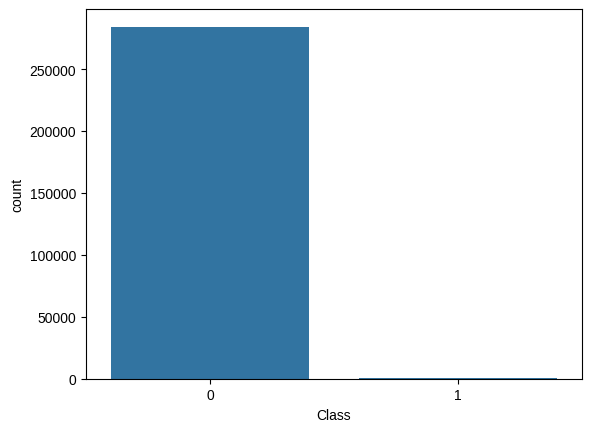

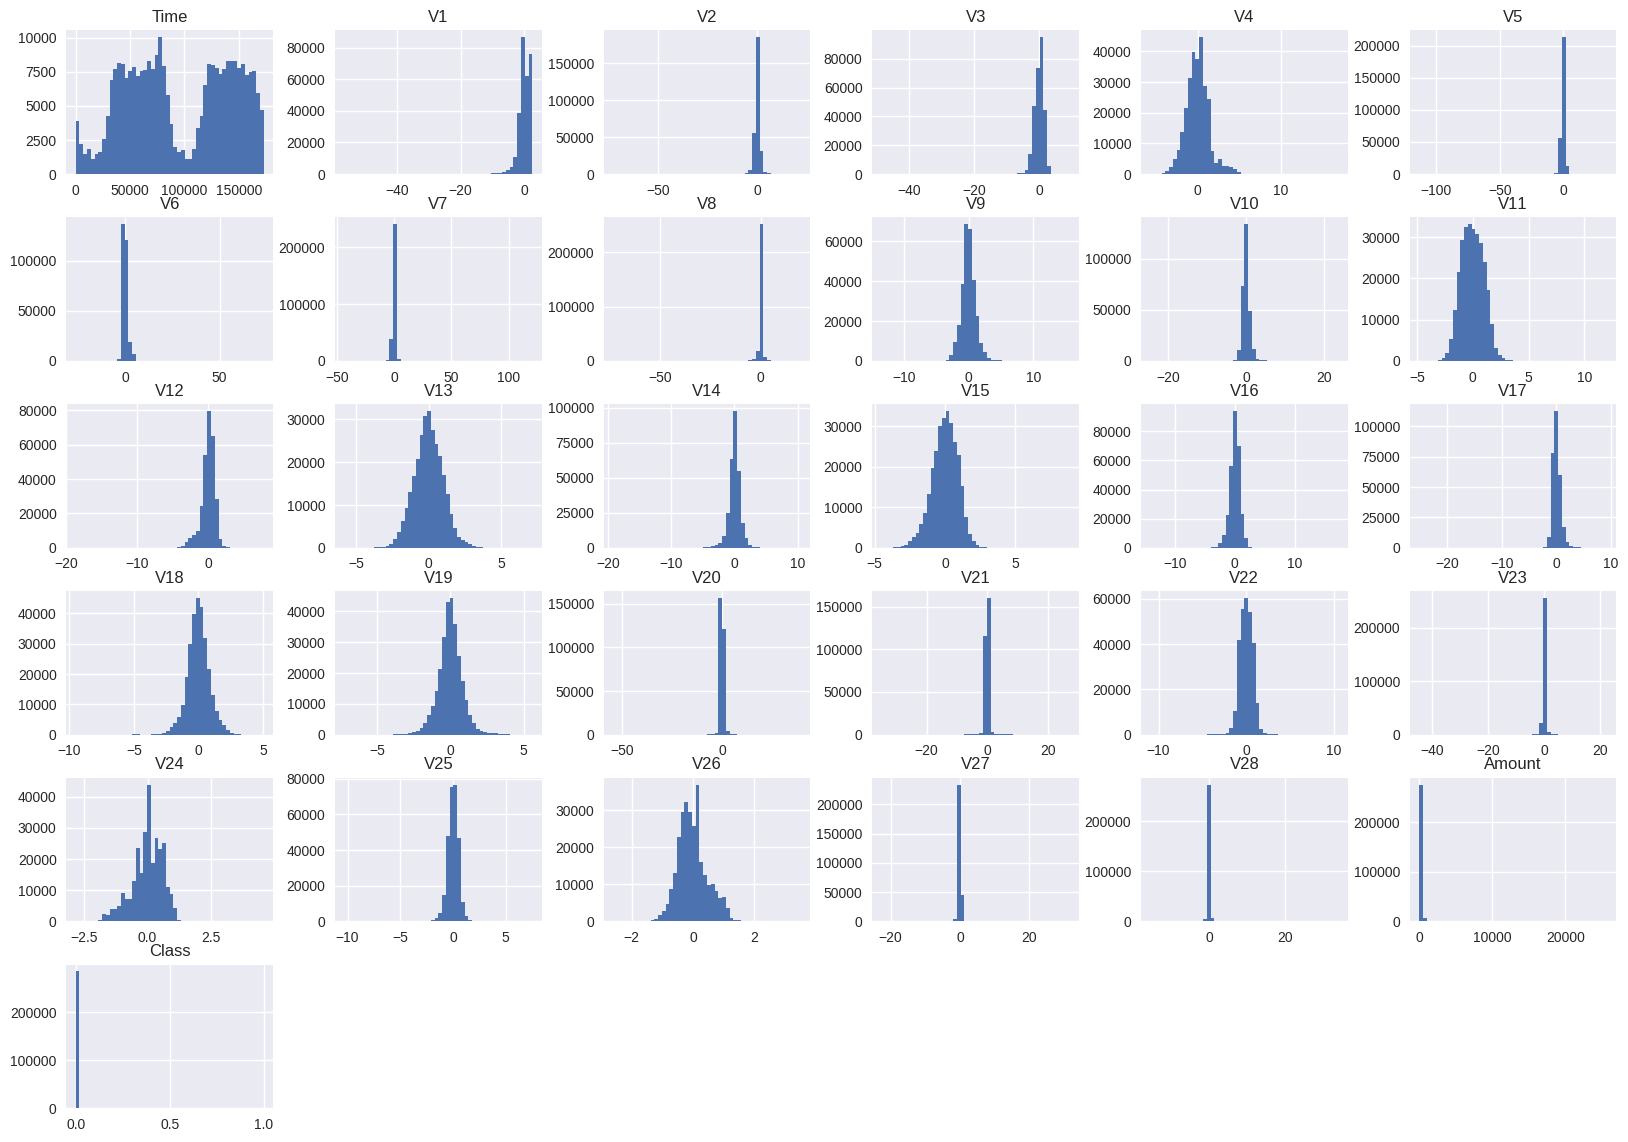

In [4]:
visualise(df)


In [5]:
x_train,y_train, x_test, y_test = trainsplit(df)


In [6]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [7]:
class_weight = [{0:w,1:y} for w in [10,100,587] for y in [10,100,587]]
class_weight


[{0: 10, 1: 10},
 {0: 10, 1: 100},
 {0: 10, 1: 587},
 {0: 100, 1: 10},
 {0: 100, 1: 100},
 {0: 100, 1: 587},
 {0: 587, 1: 10},
 {0: 587, 1: 100},
 {0: 587, 1: 587}]

 ** **Applying the grid search **

> Add blockquote



In [8]:
x_train.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
2557,-2.289565,-0.480260,0.818685,-1.706423,0.822102,-1.660326,0.944047,-0.541765,1.323156,-0.434426,...,-0.831985,-0.210837,0.914737,0.867888,0.422969,0.310584,-0.781488,0.392241,-0.147757,1.00
247823,-0.313717,-4.064342,-3.398445,0.704011,0.101662,1.529848,1.551670,-0.036774,0.015829,-0.359561,...,2.142593,0.853186,-0.091941,-0.936215,-0.833081,-0.498728,0.651183,-0.290331,0.110360,1194.28
152342,-1.809763,-0.567439,2.265186,-0.960318,-1.212537,1.516493,-1.417176,0.903421,1.961027,-0.724328,...,-0.554004,-0.509915,-0.424978,-0.268621,0.010121,0.466862,0.835540,-0.062385,0.088079,75.00
103385,1.192319,0.178575,0.141491,0.459628,-0.049959,-0.112122,-0.163883,0.155740,-0.067566,-0.130220,...,-0.149985,-0.240464,-0.739862,0.116799,-0.373837,0.125470,0.130126,-0.016956,0.011937,1.98
8771,-0.963451,0.700311,1.097333,-1.547626,0.669966,0.513533,0.333683,0.270900,1.381880,-0.659956,...,0.122458,-0.279519,-0.470181,-0.124037,-1.388839,-0.237453,0.785347,0.349708,0.216207,37.31


In [9]:
  from cuml.linear_model import LogisticRegression
  model = LogisticRegression()
  #model.fit(df.drop(['Time','target'], axis=1), df['target'])
  model = LogisticRegression(max_iter=1000)
# trying to use the GPU
  penalty = ['l1','l2']
  regularisation_strength = [0.1,0.01]
  solver = ['liblinear','saga']
  class_weight = [{0:w,1:y} for w in [1] for y in [100,587]]
  #cross_valid = [StratifiedKFold(),StratifiedGroupKFold(),StratifiedShuffleSplit()]
  parameters = dict(penalty=penalty,C=regularisation_strength,solver=solver,class_weight=class_weight)
  grid = GridSearchCV(estimator=model,param_grid=parameters,cv=StratifiedKFold(),scoring= 'recall',verbose=1,n_jobs=-1)
  grid.fit(x_train,y_train)
  print(grid.best_params_)
  grid.best_score_


Fitting 5 folds for each of 16 candidates, totalling 80 fits
[2026-03-20 05:00:00.676] [CUML] [warning] L-BFGS stopped, because the line search failed to advance (step delta = 0.000000)
{'C': 0.1, 'class_weight': {0: 1, 1: 587}, 'penalty': 'l2', 'solver': 'liblinear'}


np.float64(0.9015258215962442)

In [10]:
print(grid.best_score_)
model = grid.best_estimator_

0.9015258215962442


              precision    recall  f1-score   support

           0       1.00      0.89      0.94     85307
           1       0.01      0.96      0.03       136

    accuracy                           0.89     85443
   macro avg       0.51      0.92      0.48     85443
weighted avg       1.00      0.89      0.94     85443

0.8910033589644558
[[76000  9307]
 [    6   130]]


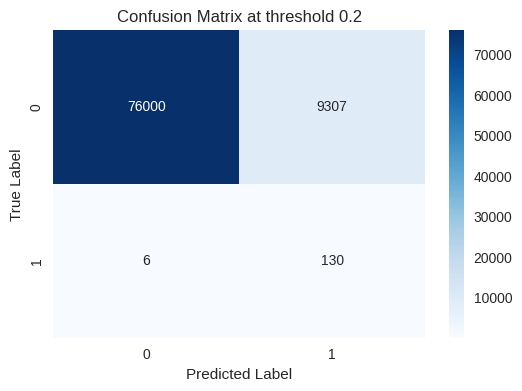

              precision    recall  f1-score   support

           0       1.00      0.89      0.94     85307
           1       0.01      0.96      0.03       136

    accuracy                           0.89     85443
   macro avg       0.51      0.92      0.48     85443
weighted avg       1.00      0.89      0.94     85443



In [11]:
threshold = 0.2
y_pred = evaluate(x_test,y_test,model,threshold)

In [12]:
#y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)#[:,1]## just the positve outcomes
y_prob = y_prob.iloc[:,1]
auc_score = roc_auc_score(y_test,y_prob)
print(auc_score)


0.9830656611173898


WHY DO I NEED IT .... THAT TOO WRT AN PROB AND WHY NOT WITH PRED

In [13]:
#score_roc_auc = roc_auc_score(y_test,model)

y_prob

0        1.000000
1        0.026224
2        0.013543
3        0.025194
4        0.020098
           ...   
85438    0.008511
85439    0.015439
85440    0.203173
85441    0.063105
85442    0.127620
Name: 1, Length: 85443, dtype: float64

TPR-y axis and FPR-x axis ====ROC Curve


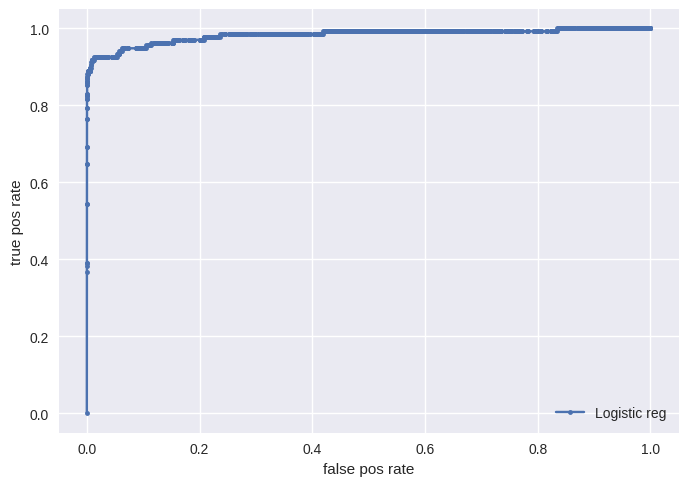

In [14]:
model_FPR, model_TPR,thresholds = roc_curve(y_test,y_prob) 
plt.plot(model_FPR,model_TPR,marker = '.',label = 'Logistic reg')
plt.xlabel("false pos rate")
plt.ylabel("true pos rate")
plt.legend()
plt.show()
